# Phase 7A Level 1R：末端覆盖修复

**目标**：保持 Level 1 的 1RC、MPC、DNN 结构、五个随机种子和门槛，只修复 SOC 0.74–0.799 的末端降流标签覆盖。

本 Notebook 只读取冻结结果，不重新训练或求解。只有教师确定性、双冻结离线测试和完整同模型闭环全部通过，才允许进入 Level 2。

## 1. 读取独立 Level 1R 产物

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
OUT = ROOT / 'outputs' / 'phase7a_level1r_terminal_coverage'
DATA = ROOT / 'data' / 'phase7a_level1r_terminal_coverage'
metrics = json.loads((OUT / 'metrics.json').read_text(encoding='utf-8'))
offline = pd.read_csv(OUT / 'dnn_offline_metrics.csv')
closed = pd.read_csv(DATA / 'closed_loop_metrics.csv')
terminal = pd.read_csv(DATA / 'terminal_teacher_dataset.csv')
tail = pd.read_csv(DATA / 'tail_training_teacher_dataset.csv')
print(metrics['study_name'], metrics['status'])

phase7a_level1r_terminal_coverage_repair completed


## 2. 冻结测试保护和数据覆盖合同

In [2]:
display(pd.DataFrame([metrics['frozen_test_contract']]))
display(pd.DataFrame([metrics['terminal_teacher']]))
assert metrics['frozen_test_contract']['preserved']
assert metrics['terminal_teacher']['attempted_trajectories'] == 160
assert metrics['terminal_teacher']['sample_count'] == 3840
assert metrics['terminal_teacher']['success']

,trajectory_count,sample_count,frozen_rows_sha256_before,frozen_rows_sha256_after,source_file_sha256_before,source_file_sha256_after,terminal_test_rows_sha256_before,terminal_test_rows_sha256_after,preserved
0,36,288,e813766c6d097cb3461225be3bdb2b1cdfc634476774a4...,e813766c6d097cb3461225be3bdb2b1cdfc634476774a4...,623386bad34b09370f3353c36323b3747839f5f6e53c1b...,623386bad34b09370f3353c36323b3747839f5f6e53c1b...,4b61aca6a8aaa8248ffbd8d919a070660e2c107523aa28...,4b61aca6a8aaa8248ffbd8d919a070660e2c107523aa28...,True


,attempted_trajectories,accepted_trajectories,acceptance_fraction,sample_count,low_current_label_count,taper_current_label_count,checks,success
0,160,160,1.0,3840,308,2832,"{'acceptance': True, 'trajectory_length': True...",True


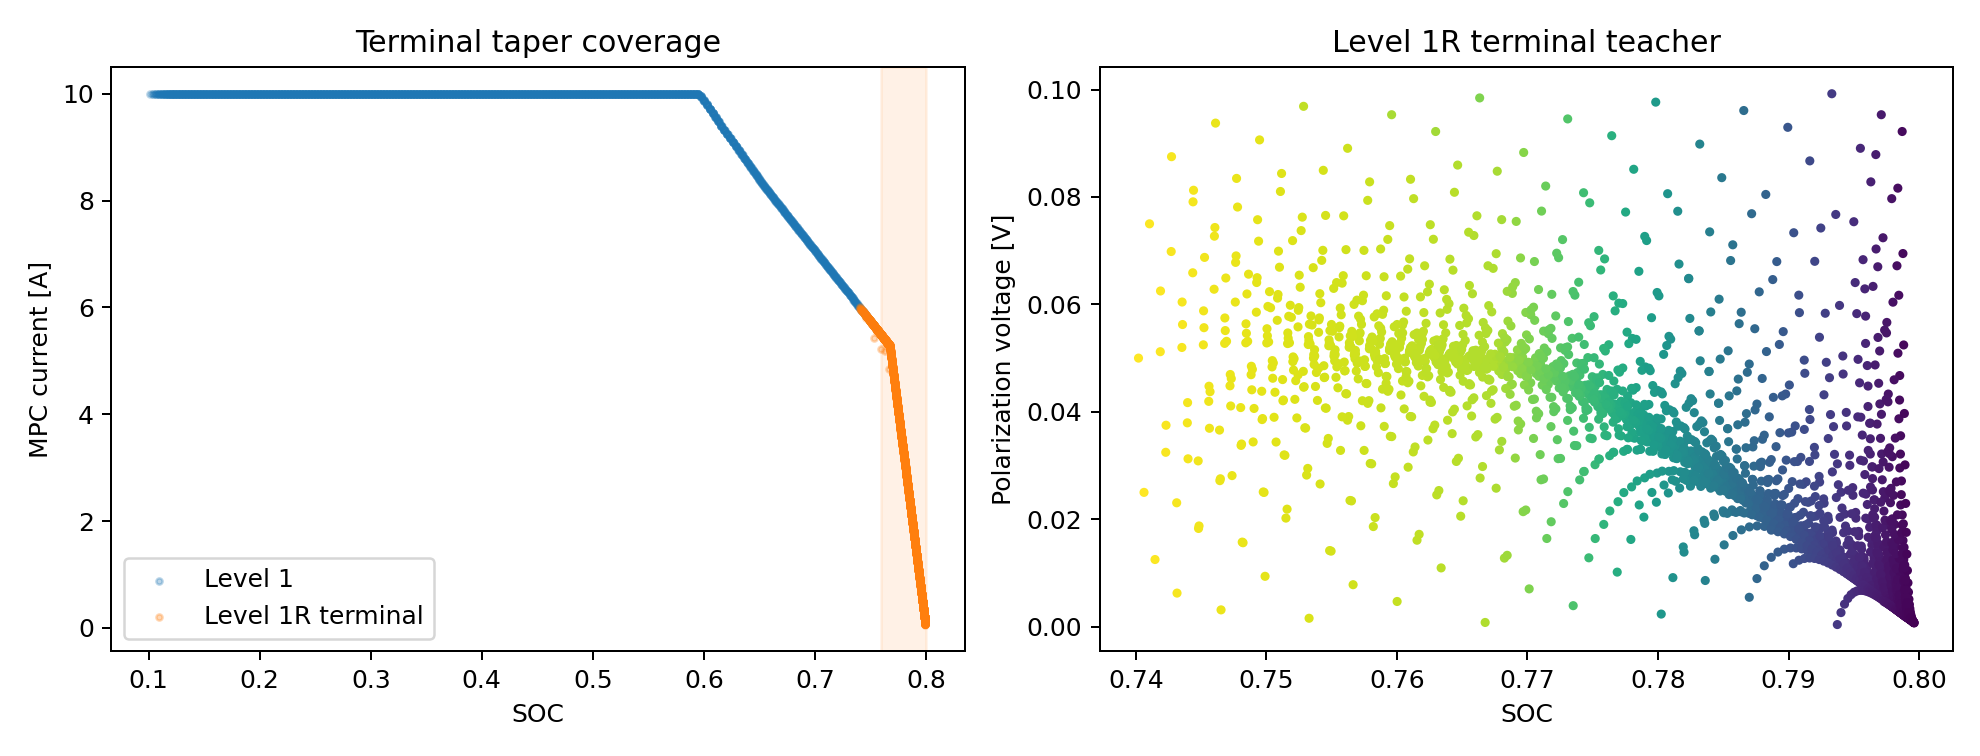

In [3]:
display(Image(filename=str(OUT / 'figures' / 'terminal_coverage_repair.png')))

## 3. 末端 100×15 多起点确定性审计

In [4]:
audit = metrics['terminal_teacher_audit']
display(pd.DataFrame([{
    'states': audit['state_count'],
    'warm_starts_per_state': audit['warm_starts_per_state'],
    'multivalued_fraction': audit['near_optimal_multivalued_fraction'],
    'action_range_p95_A': audit['near_optimal_first_action_range_p95_a'],
    'passed': audit['success'],
}]))
assert audit['success']

,states,warm_starts_per_state,multivalued_fraction,action_range_p95_A,passed
0,100,15,0.0,0.016502,True


## 4. 原始与末端双冻结测试

In [5]:
view = offline[['seed','test_nrmse','terminal_test_nrmse']].copy()
view['original_test_nrmse_percent'] = 100 * view.pop('test_nrmse')
view['terminal_test_nrmse_percent'] = 100 * view.pop('terminal_test_nrmse')
display(view)
assert (view.original_test_nrmse_percent < 1).all()
assert (view.terminal_test_nrmse_percent < 1).all()

,seed,original_test_nrmse_percent,terminal_test_nrmse_percent
0,22,0.258082,0.309836
1,42,0.263740,0.311027
2,73,0.267734,0.343224
3,101,0.212744,0.338717
4,137,0.291248,0.306983


## 5. 完整同模型闭环

,seed,target_reach_fraction,maximum_voltage_violation_v,speedup,current_nrmse_percent,charge_time_gap_percent
0,22,1.0,0.0,1011.879968,0.281683,2.037060
1,42,1.0,0.0,988.131227,0.315058,2.261760
2,73,1.0,0.0,1088.805695,0.307425,3.109372
3,101,1.0,0.0,972.684523,0.281003,1.413052
4,137,1.0,0.0,982.341349,0.310214,1.596463


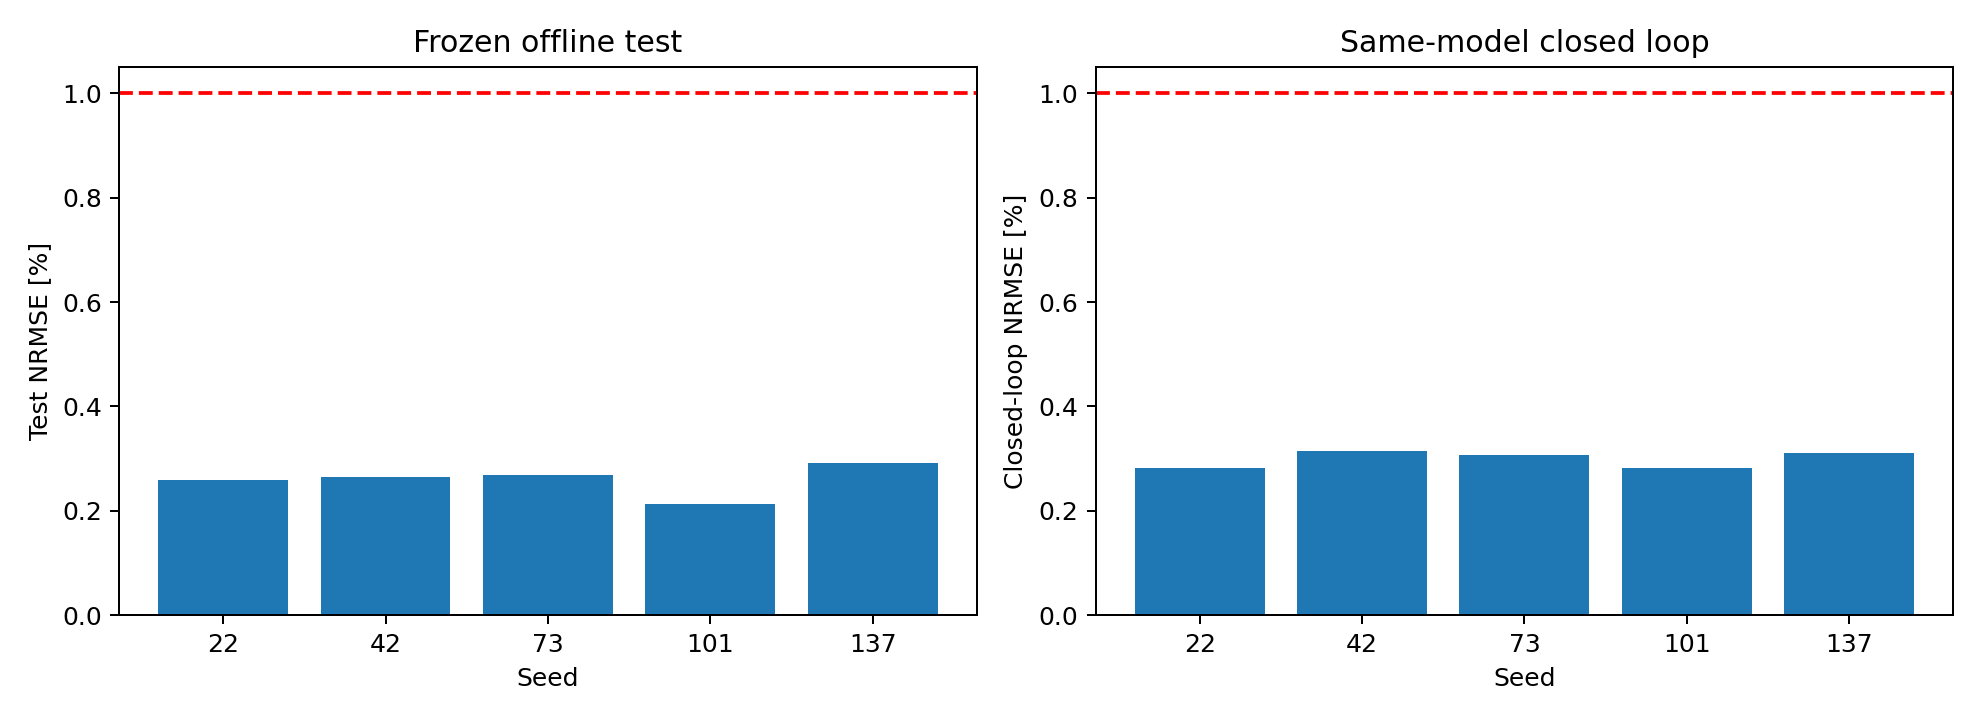

In [6]:
view = closed[['seed','mean_current_nrmse','mean_charge_time_gap_fraction','target_reach_fraction','maximum_voltage_violation_v','speedup']].copy()
view['current_nrmse_percent'] = 100 * view.pop('mean_current_nrmse')
view['charge_time_gap_percent'] = 100 * view.pop('mean_charge_time_gap_fraction')
display(view)
display(Image(filename=str(OUT / 'figures' / 'dnn_seed_stability.png')))

### 闭环解释

覆盖修复把五种子闭环电流 NRMSE 从 Level 1 的约 8.9% 降至约 0.28%–0.32%，并保持目标到达、安全和高加速。但充电时间是目标阈值首次穿越的离散步数指标，五种子中仍有三个超过 2% 门槛，因此严格判定不能通过。

## 6. 阶段判定

In [7]:
display(pd.DataFrame([metrics['decision']['checks']]))
print(metrics['decision']['conclusion'])
print('进入 Level 2:', metrics['decision']['proceed_to_level2'])
assert metrics['status'] == 'completed'
assert metrics['decision']['checks']['frozen_test_preserved']
assert metrics['decision']['checks']['terminal_teacher_passed']
assert metrics['decision']['checks']['terminal_determinism_passed']
assert metrics['decision']['checks']['dual_offline_tests_passed']
assert not metrics['decision']['checks']['same_model_closed_loop_passed']
assert not metrics['decision']['proceed_to_level2']

,frozen_test_preserved,terminal_teacher_passed,terminal_determinism_passed,dual_offline_tests_passed,same_model_closed_loop_passed
0,True,True,True,True,False


Level 1R 未通过，保持停止在 Level 1
进入 Level 2: False


## 最终记录

- Level 1：严格门槛未通过；教师确定性与 pure DNN 局部逼近能力通过；失败源于末端降流区域覆盖不足。
- Level 1R：覆盖缺口已显著修复，闭环电流逼近通过，但五种子充电时间稳定性仍未达到严格门槛。
- 决策：保持停止在 Level 1，不进入 Level 2。